# 02 — Feature engineering

Features historiques + embeddings **SBERT** (`all-MiniLM-L6-v2`) + similarité cosinus diff↔test.

**Entrée** : `artifacts/dataset.pkl`, `artifacts/commits.pkl`.  
**Sortie** : `artifacts/dataset_features.pkl`, `artifacts/embeddings_sbert.pkl`.

In [1]:
# ── Chemins relatifs au package (portable) ──
from pathlib import Path
import os
ROOT = Path.cwd()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent          
elif (ROOT / 'scripts').exists():
    pass                        
DATA = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
ARTIFACTS.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
print('Racine du package :', ROOT)

Racine du package : c:\Users\LEGION\OneDrive\Bureau\package_evaluation


In [2]:
import pandas as pd, numpy as np, re, pickle
from datetime import datetime
from collections import Counter
from scipy.stats import spearmanr
import warnings; warnings.filterwarnings('ignore'); np.random.seed(42)

# Chargement des artefacts produits par le notebook précédent (01) :
# le dataset de base (paires commit-test + labels) et les métadonnées des commits.
df = pd.read_pickle(ARTIFACTS/'dataset.pkl')
COMMITS = pickle.load(open(ARTIFACTS/'commits.pkl','rb'))

def read_file(path):
    """Lit un fichier texte en gérant automatiquement son encodage.

    Tente successivement UTF-16 (détecté via le BOM), UTF-8, puis Latin-1
    en dernier recours, afin de lire de manière robuste des fichiers
    d'encodages hétérogènes.

    Args:
        path: Chemin du fichier à lire.

    Returns:
        Le contenu du fichier sous forme de chaîne, ou une chaîne vide
        si le chemin est invalide ou le fichier inexistant.
    """
    if not path or not os.path.exists(str(path)): return ''
    with open(path,'rb') as f: raw=f.read()
    if raw[:2]==b'\xff\xfe': return raw.decode('utf-16',errors='replace')
    try: return raw.decode('utf-8',errors='replace')
    except: return raw.decode('latin-1',errors='replace')


def read_diff_for_embedding(path, max_chars=3000): return read_file(path)[:max_chars]

"""Lit un diff en tronquant son contenu pour l'encodage SBERT.

    La troncature limite la taille du texte transmis au modèle d'embedding,
    les premiers caractères du diff étant les plus représentatifs des
    modifications introduites.

    Args:
        path: Chemin du fichier de diff.
        max_chars: Nombre maximal de caractères conservés (défaut : 3000).

    Returns:
        Les premiers caractères du diff sous forme de chaîne.
    """
print('Dataset chargé :', df.shape)

Dataset chargé : (263649, 27)


## Features historiques

In [3]:
#ÉTAPE 6 : Features historiques 
commits_ordered = sorted(df['commit_date'].unique())
df['module_rel_hist'] = 0.0
df['test_rel_hist'] = 0.0
df['nb_past_commits'] = 0

for i, date in enumerate(commits_ordered):
    if i == 0: continue
    past = df[df.commit_date.isin(commits_ordered[:i])]
    mod_r = past.groupby('module')['relevance_score'].mean().to_dict()
    test_r = past.groupby('test_name')['relevance_score'].mean().to_dict()
    mask = df.commit_date == date
    df.loc[mask, 'module_rel_hist'] = df.loc[mask, 'module'].map(mod_r).fillna(0)
    df.loc[mask, 'test_rel_hist'] = df.loc[mask, 'test_name'].map(test_r).fillna(0)
    df.loc[mask, 'nb_past_commits'] = i

print('Features historiques calculées')

Features historiques calculées


## Embeddings SBERT + similarité cosinus

In [4]:
# ÉTAPE 7 : Embeddings SBERT
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Chargement du modèle SBERT pré-entraîné. all-MiniLM-L6-v2 produit des
# embeddings de dimension 384 et offre un bon compromis entre qualité
# sémantique et rapidité d'encodage.
print('Chargement SBERT all-MiniLM-L6-v2...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Encodage de chaque diff de commit en un vecteur sémantique unique.
# Le diff est tronqué en amont (read_diff_for_embedding) ; un diff vide
# est représenté par un vecteur nul de dimension 384.
print('\nEncodage des 10 diffs...')
diff_emb_sbert = {}
for cid, info in COMMITS.items():
    txt = read_diff_for_embedding(info['diff'])
    diff_emb_sbert[info['hash']] = sbert.encode([txt], convert_to_numpy=True)[0] if txt else np.zeros(384)
    print(f"  {cid} ({info['hash'][:8]}) : {len(txt):,} chars")

# Encodage des noms de tests. On encode uniquement les tests UNIQUES
# (un même test apparaît dans plusieurs commits) afin d'éviter de recalculer
# le même embedding plusieurs fois ; l'encodage par batch accélère le calcul.
unique_tests = df['test_name'].unique().tolist()
print(f'\nEncodage de {len(unique_tests):,} tests uniques...')
test_emb_sbert_arr = sbert.encode(unique_tests, batch_size=256, show_progress_bar=True, convert_to_numpy=True)
# Dictionnaire {nom_du_test: embedding} pour une réutilisation rapide ensuite
test_emb_sbert = dict(zip(unique_tests, test_emb_sbert_arr))
print(f'Shape : {test_emb_sbert_arr.shape}')

Chargement SBERT all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Encodage des 10 diffs...
  commit01 (00a07d87) : 3,000 chars
  commit02 (2e99e132) : 3,000 chars
  commit03 (2ad3f3bc) : 3,000 chars
  commit04 (ae183639) : 3,000 chars
  commit05 (0f00c98b) : 3,000 chars
  commit06 (779aaf79) : 934 chars
  commit07 (ecb62ac0) : 2,594 chars
  commit08 (70361b33) : 3,000 chars
  commit09 (10428c1e) : 3,000 chars
  commit10 (967c24d9) : 1,538 chars
  commit11 (f7f85f08) : 3,000 chars
  commit12 (85111140) : 3,000 chars
  commit13 (e8d4ea2d) : 3,000 chars
  commit14 (50e898d3) : 3,000 chars
  commit15 (3d850f26) : 726 chars
  commit16 (fbdac503) : 2,334 chars
  commit17 (da82c1a6) : 3,000 chars
  commit18 (442cf8de) : 2,424 chars
  commit19 (63d813f0) : 3,000 chars
  commit20 (348e6698) : 2,083 chars
  commit21 (ac72e930) : 446 chars
  commit22 (c3b9590f) : 3,000 chars
  commit23 (5d58b75f) : 1,733 chars
  commit24 (03b8646d) : 1,533 chars
  commit25 (5be6062d) : 2,650 chars
  commit26 (6f42cf7f) : 3,000 chars
  commit27 (eebe9b13) : 3,000 chars
  commit

Batches:   0%|          | 0/36 [00:00<?, ?it/s]

Shape : (9009, 384)


In [5]:
# Calcul de la similarité sémantique pour chaque paire commit-test.
# Pour chaque ligne, on récupère l'embedding du diff (via le hash du commit)
# et celui du nom de test, puis on mesure leur similarité cosinus. Un embedding
# absent est remplacé par un vecteur nul de dimension 384.
print('Calcul des similarités...')
sims = []
for _, row in df.iterrows():
    de = diff_emb_sbert.get(row['commit_hash'], np.zeros(384))
    te = test_emb_sbert.get(row['test_name'], np.zeros(384))
    sims.append(float(cosine_similarity([de], [te])[0][0]))
df['similarity_score'] = sims

# Contrôle du pouvoir discriminant de SBERT : similarité moyenne par niveau
# de pertinence. On s'attend à une similarité croissante avec le score de
# pertinence si le signal sémantique est informatif.
print('Similarités calculées')
print('\n── Similarité par niveau de pertinence ──')
for level in sorted(df.relevance_score.unique()):
    d = df[df.relevance_score == level]
    print(f"  score={level:.1f} : sim_moy={d.similarity_score.mean():.4f} ({len(d):,} tests)")

# Corrélation de Spearman entre similarité SBERT et score de pertinence.
# Une corrélation positive significative confirme que la similarité sémantique
# constitue un indicateur pertinent (validation de l'hypothèse H1).
corr, pval = spearmanr(df.similarity_score, df.relevance_score)
print(f'\n  Corrélation Spearman : {corr:.4f} (p={pval:.2e})')

Calcul des similarités...
Similarités calculées

── Similarité par niveau de pertinence ──
  score=0.0 : sim_moy=0.1700 (234,257 tests)
  score=0.1 : sim_moy=0.2449 (11,634 tests)
  score=0.2 : sim_moy=0.2492 (6,853 tests)
  score=0.5 : sim_moy=0.2755 (9,563 tests)
  score=0.6 : sim_moy=0.1787 (4 tests)
  score=0.8 : sim_moy=0.2927 (1,309 tests)
  score=1.0 : sim_moy=0.4266 (29 tests)

  Corrélation Spearman : 0.2558 (p=0.00e+00)


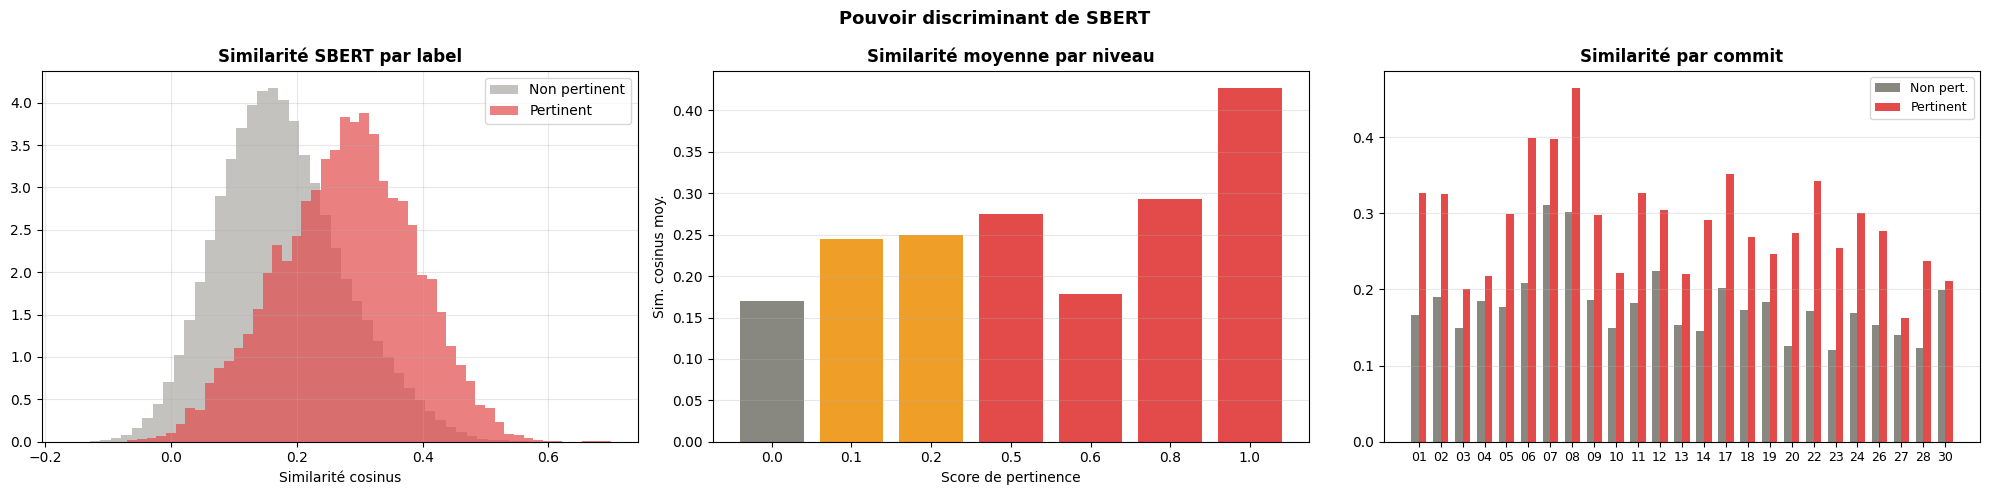

In [6]:
#ÉTAPE 9 : Visualisation similarité 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Distribution par label
axes[0].hist(df[df.label_relevant==0].similarity_score, bins=50, alpha=0.5,
            color='#888780', label='Non pertinent', density=True)
axes[0].hist(df[df.label_relevant==1].similarity_score, bins=50, alpha=0.7,
            color='#E24B4A', label='Pertinent', density=True)
axes[0].set_title('Similarité SBERT par label', fontweight='bold')
axes[0].set_xlabel('Similarité cosinus'); axes[0].legend(); axes[0].grid(alpha=0.3)

# 2. Par niveau de pertinence
levels = sorted(df.relevance_score.unique())
sim_means = [df[df.relevance_score==l].similarity_score.mean() for l in levels]
colors_l = ['#888780' if l==0 else '#EF9F27' if l<0.5 else '#E24B4A' for l in levels]
axes[1].bar([f'{l:.1f}' for l in levels], sim_means, color=colors_l)
axes[1].set_title('Similarité moyenne par niveau', fontweight='bold')
axes[1].set_xlabel('Score de pertinence'); axes[1].set_ylabel('Sim. cosinus moy.')
axes[1].grid(axis='y', alpha=0.3)

# 3. Par commit (pertinent vs non)
data_p = []
for cid in df.commit_id.unique():
    d = df[df.commit_id == cid]
    if d.label_relevant.nunique() > 1:
        data_p.append({'commit': cid[-2:],
                    'rel': d[d.label_relevant==1].similarity_score.mean(),
                    'nrel': d[d.label_relevant==0].similarity_score.mean()})
if data_p:
    dp = pd.DataFrame(data_p)
    x = np.arange(len(dp)); w = 0.35
    axes[2].bar(x-w/2, dp['nrel'], w, color='#888780', label='Non pert.')
    axes[2].bar(x+w/2, dp['rel'], w, color='#E24B4A', label='Pertinent')
    axes[2].set_xticks(x); axes[2].set_xticklabels(dp['commit'], fontsize=9)
    axes[2].legend(fontsize=9)
axes[2].set_title('Similarité par commit', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Pouvoir discriminant de SBERT', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Sauvegarde

In [ ]:
df.to_pickle(ARTIFACTS/'dataset_features.pkl')
pickle.dump({'test_emb_sbert':test_emb_sbert,'diff_emb_sbert':diff_emb_sbert}, open(ARTIFACTS/'embeddings_sbert.pkl','wb'))
print('Artefacts 02 sauvegardés')

 Artefacts 02 sauvegardés
